<h1 style='color:Green'>Logistic Regression</h1>

[View the PDF](./004-Logistic-Regression.pdf)

In [21]:
from IPython.display import IFrame
IFrame('004-Logistic-Regression.pdf', width=650, height=600)

# Binary Classification

In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-darkgrid")

In [4]:
#print(plt.style.available)

In [5]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

In [6]:
#Step-1 Generate Toy(Dummy) Dataset 
X, y = make_blobs(n_samples=2000, n_features=2, cluster_std=3, centers=2, random_state=42)
n_features=2

In [7]:
print(X.shape, y.shape)

(2000, 2) (2000,)


In [8]:
print(y)

[0 0 0 ... 1 0 1]


In [9]:
#Step-2 Visualise Dataset 
def visualise(X,y):
    plt.scatter(X[:,0],X[:,1], c=y, cmap="viridis")
    plt.show()

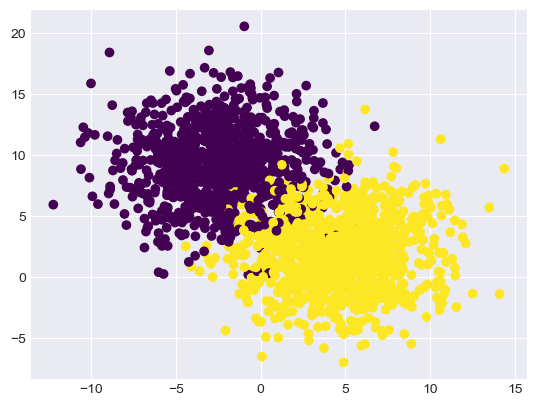

In [10]:
visualise(X,y)

In [11]:
#Step-3 Normalise 
def normalise(X): 
    u = X.mean(axis=0)
    std = X.std(axis=0) 
    return (X-u)/std  

In [12]:
X = normalise(X)

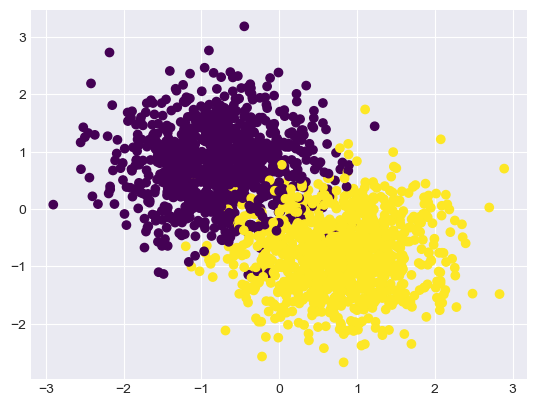

In [13]:
visualise(X,y)

In [14]:
#Step-4 Train Test Split 
XT, Xt, yT, yt = train_test_split(X, y, test_size=0.25, shuffle=False, random_state=0) 

In [15]:
print(XT.shape, yT.shape, Xt.shape, yt.shape)

(1500, 2) (1500,) (500, 2) (500,)


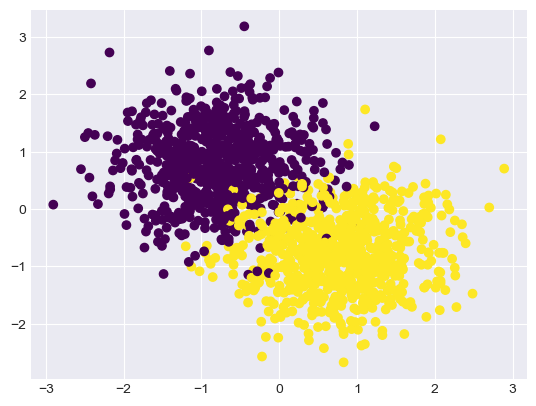

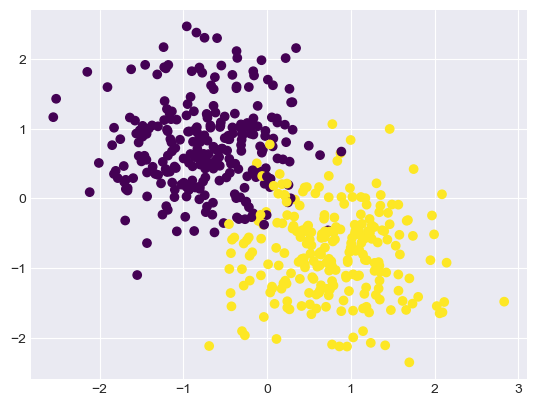

In [16]:
visualise(XT,yT) 
visualise(Xt,yt)

In [17]:
#Model 
def sigmoid(z): 
    return 1/(1+np.exp(-z))

def hypothesis(X, theta): 
    return sigmoid(np.dot(X,theta))

#Binary Cross Entropy 
def error(y, yp): 
    loss = -np.mean( y*np.log(yp) + (1-y)*np.log(1-yp) ) 
    return loss 

def gradient(X, y, yp): 
    m = X.shape[0]
    grad = -(1/m) * np.dot(X.T, (y-yp)) 
    return grad 

def train(X, y, lr=0.1, max_iters=100): 
    theta = np.random.randn(n_features+1, 1) 

    error_list = []
    
    for i in range(max_iters): 
        yp = hypothesis(X, theta)
        e = error(y, yp) 
        error_list.append(e)
        grad = gradient(X, y, yp) 
        theta = theta - lr*grad
    plt.plot(error_list)
    return theta

def predict(X, theta): 
    h = hypothesis(X,theta)
    preds = np.zeros((X.shape[0],1),dtype='int')
    preds[h>0.5] = 1 
    return preds

def accuracy(X, y, theta): 
    preds = predict(X,theta)
    return ((y==preds).sum())/y.shape[0] * 100 

In [18]:
#Preprocessing
def addExtraColumn(X): 
    if X.shape[1] == n_features: 
        ones = np.ones((X.shape[0],1))
        X = np.hstack((ones,X))

    return X 

In [19]:
XT = addExtraColumn(XT)
Xt = addExtraColumn(Xt)

In [20]:
yT = yT.reshape(-1,1)
yt = yt.reshape(-1,1)

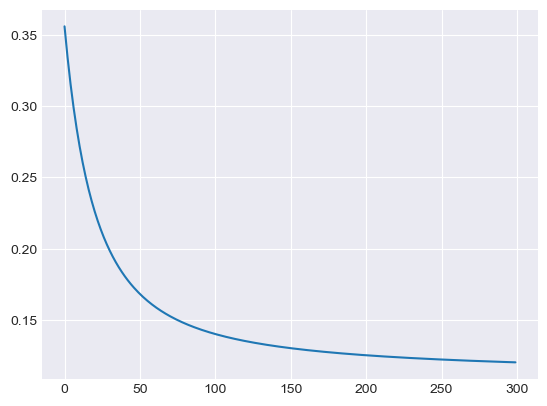

In [21]:
theta = train(XT, yT, lr=0.2, max_iters=300)

In [22]:
theta

array([[-0.00526752],
       [ 2.50859861],
       [-3.06104423]])

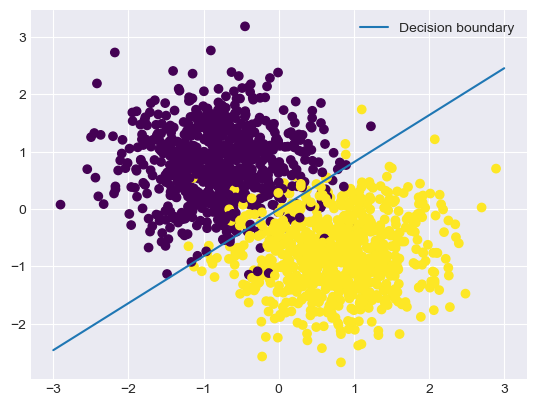

In [23]:
#Visualise Decision Boundary 
plt.scatter(XT[:,1],XT[:,2], c=yT, cmap="viridis")

x1 = np.linspace(-3,3,6)
x2 = -(theta[0]+theta[1]*x1)/theta[2]
plt.plot(x1,x2,label="Decision boundary")
plt.legend()

plt.show()

<h1><span style='color:Orange'>Step-4</span> Predications</h1>

### Thesholding- Since the model predicts only probabilities, we need to put a certain threshold to decide the final label  
##### To predict the Y label, we have to set a probability cutoff, or threshold, for a positive result. 

In [26]:
#Predictions 
preds = predict(Xt, theta)

In [27]:
#Train accuracy 
accuracy(XT,yT,theta)

95.66666666666667

In [28]:
#Test accuracy 
accuracy(Xt,yt,theta)

95.8

<h1 style='color:green'>SkLearn Library</h1>

In [83]:
from sklearn.linear_model import LogisticRegression

In [93]:
#Create
X,y = make_blobs(n_samples=2000, n_features=2, cluster_std=3, centers=2, random_state=42)
model = LogisticRegression()

In [101]:
#Training

model.fit(X,y)

LogisticRegression()

In [103]:
#Predictions 
model.predict(X)

array([0, 0, 0, ..., 1, 0, 1])

In [105]:
#Scoring
model.score(X,y)

0.96

# Multiclass Classification  
- One vs Rest
- One vs One

In [166]:
from IPython.display import IFrame
IFrame('Multiclass.pdf', width=650, height=600)


## One vs Rest Strategy(ovr)

In [141]:
X, y = make_blobs(n_samples=2000, n_features=2, cluster_std=3, centers=3, random_state=42)

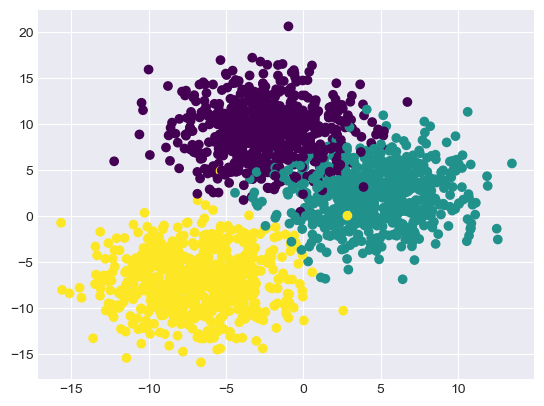

In [143]:
plt.scatter(X[:,0],X[:,1], c=y, cmap='viridis')
plt.show()

In [144]:
print(np.unique(y,return_counts=True))

(array([0, 1, 2]), array([667, 667, 666], dtype=int64))


In [148]:
model = LogisticRegression(multi_class='ovr')

In [154]:
model.fit(X,y)

LogisticRegression(multi_class='ovr')

In [156]:
model.predict(X)

array([1, 1, 1, ..., 1, 2, 1])

In [158]:
model.score(X,y)

0.9605

# One vs One Strategy(ovo)

<img src='ovo.png'>